# Classification Algorithms, Model Selection & Evaluation - Heart Disease Dataset

**Problem Statement:** Predict a category — build at least 3 classification models
(Logistic Regression, Decision Tree, Random Forest) to predict the `target` class (presence of heart disease).
Select the best-performing model and justify the choice using Accuracy, Precision, Recall, F1-score, a confusion matrix and ROC-AUC.

## 1. Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score)

import warnings
warnings.filterwarnings("ignore")

## 2. Loading the Dataset

In [2]:
df = pd.read_csv("heart.csv")

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.shape

(1025, 14)

* The dataset has 1025 rows and 14 columns, with `target` (0 = no heart disease, 1 = heart disease) as the class to predict.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


* All 14 columns are numeric (int/float), so no categorical encoding is required.

In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


* Features like `chol`, `trestbps` and `thalach` vary widely in scale, so scaling will help distance-based models like KNN and Logistic Regression.

## 3. Data Quality Checks

In [7]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

* There are zero missing values across all columns.

In [8]:
df.duplicated().sum()

np.int64(723)

* There are 723 duplicate rows out of 1025, a known characteristic of this dataset since it only has a handful of discrete/categorical feature combinations; we remove them to avoid the same patient profile being counted many times and biasing the train/test split.

In [9]:
df = df.drop_duplicates().reset_index(drop=True)
df.shape

(302, 14)

* After removing duplicates, 302 unique patient records remain for analysis and modeling.

In [10]:
df['target'].value_counts()

target
1    164
0    138
Name: count, dtype: int64

* The target classes are reasonably balanced (roughly 54% disease vs 46% no disease), so accuracy alone will still be meaningful but we track Precision/Recall/F1 as well.

## 4. Exploratory Data Analysis

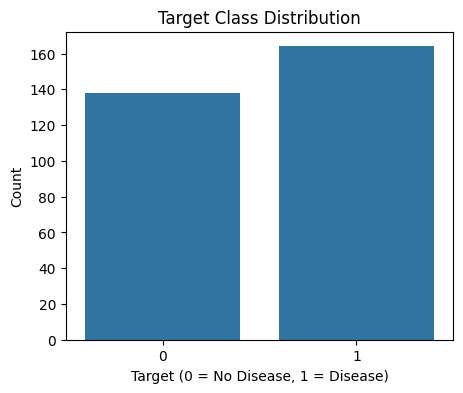

In [11]:
plt.figure(figsize=(5,4))
sns.countplot(x='target', data=df)
plt.title("Target Class Distribution")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Count")
plt.show()

* The two classes are close in size, confirming the dataset is not heavily imbalanced.

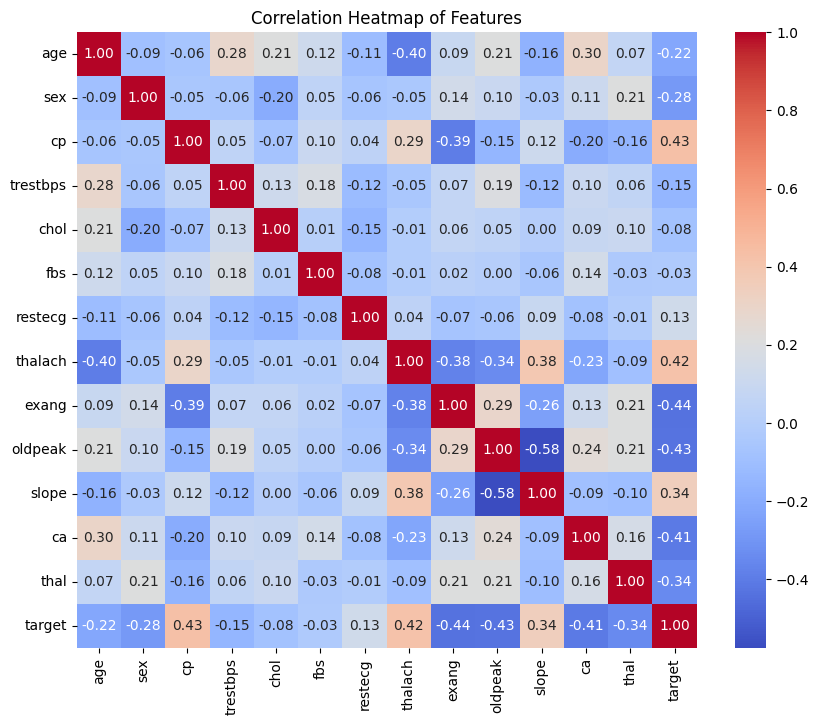

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap of Features")
plt.show()

* `cp` (chest pain type), `thalach` (max heart rate) and `slope` show the strongest positive correlation with `target`, while `exang`, `oldpeak` and `ca` show the strongest negative correlation.

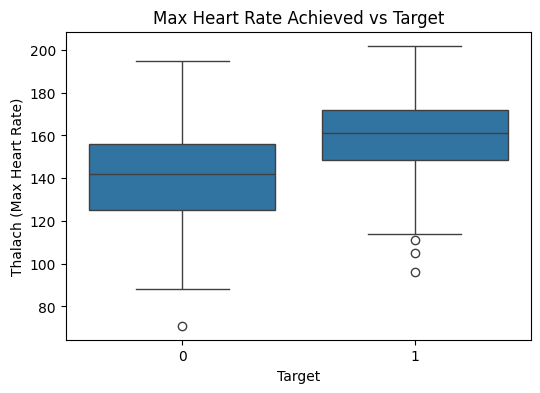

In [13]:
plt.figure(figsize=(6,4))
sns.boxplot(x='target', y='thalach', data=df)
plt.title("Max Heart Rate Achieved vs Target")
plt.xlabel("Target")
plt.ylabel("Thalach (Max Heart Rate)")
plt.show()

* Patients with heart disease tend to have a higher maximum heart rate achieved during testing than those without.

## 5. Defining Features (X) and Target (y)

In [14]:
X = df.drop("target", axis=1)
y = df["target"]
X.shape, y.shape

((302, 13), (302,))

## 6. Train / Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape

((241, 13), (61, 13))

* The data is split 80/20 with stratification on `target`, giving 241 training rows and 61 test rows while preserving the class ratio in both sets.

## 7. Feature Scaling

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

* Scaling is fit only on the training data and applied to the test data to avoid data leakage; this matters most for Logistic Regression and KNN, which are distance/gradient sensitive.

## 8. Model 1: Logistic Regression

In [17]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

## 9. Model 2: Decision Tree Classifier

In [18]:
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

* Decision Tree uses the unscaled features directly, since tree-based splits are not affected by feature scale.

## 10. Model 3: Random Forest Classifier

In [19]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

## 11. Model 4 (Bonus): K-Nearest Neighbors

In [20]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
y_proba_knn = knn.predict_proba(X_test_scaled)[:, 1]

* A fourth model (KNN) is included beyond the required 3, to give a broader comparison and a stronger basis for selecting the best model.

## 12. Metrics Comparison Table

In [21]:
def evaluate(y_true, y_pred, y_proba, model_name):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba)
    }

results = [
    evaluate(y_test, y_pred_lr, y_proba_lr, "Logistic Regression"),
    evaluate(y_test, y_pred_dt, y_proba_dt, "Decision Tree"),
    evaluate(y_test, y_pred_rf, y_proba_rf, "Random Forest"),
    evaluate(y_test, y_pred_knn, y_proba_knn, "KNN"),
]

results_df = pd.DataFrame(results).set_index("Model").round(3)
results_df.sort_values("F1-score", ascending=False)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Logistic Regression,0.803,0.800,0.848,0.824,0.871
KNN,0.787,0.778,0.848,0.812,0.860
Decision Tree,0.770,0.806,0.758,0.781,0.832
Random Forest,0.754,0.765,0.788,0.776,0.870


* Logistic Regression achieves the highest Accuracy, F1-score and ROC-AUC among the four models, with Random Forest close behind on ROC-AUC — a linear decision boundary already separates the classes well on this feature set.

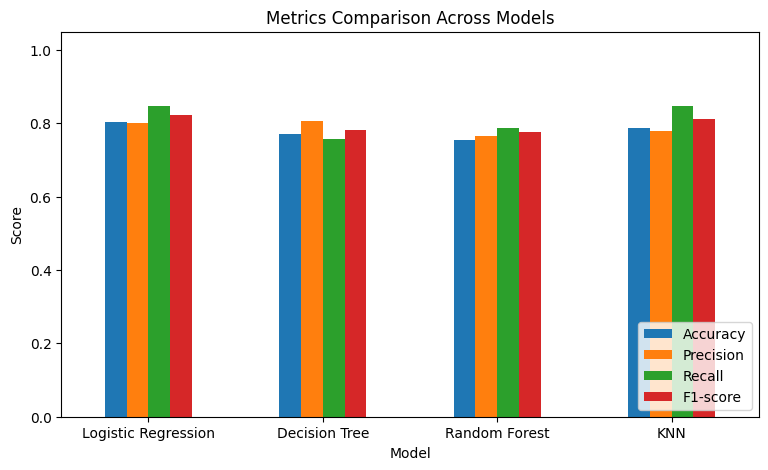

In [22]:
results_df[['Accuracy','Precision','Recall','F1-score']].plot(kind='bar', figsize=(9,5))
plt.title("Metrics Comparison Across Models")
plt.ylabel("Score")
plt.ylim(0,1.05)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

* Logistic Regression leads on Accuracy and F1-score, KNN matches its Recall, and the Decision Tree trails behind the other three models on nearly every metric.

## 13. ROC Curve Comparison

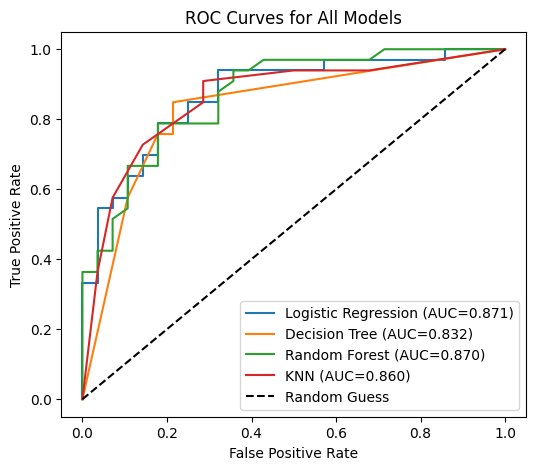

In [23]:
plt.figure(figsize=(6,5))
for name, proba in [("Logistic Regression", y_proba_lr), ("Decision Tree", y_proba_dt),
                     ("Random Forest", y_proba_rf), ("KNN", y_proba_knn)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'k--', label="Random Guess")
plt.title("ROC Curves for All Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

* Logistic Regression's ROC curve sits closest to the top-left corner with the highest AUC, with Random Forest almost overlapping it, while the Decision Tree's curve is visibly the furthest from the ideal corner.

## 14. Confusion Matrix for the Best Model (Logistic Regression)

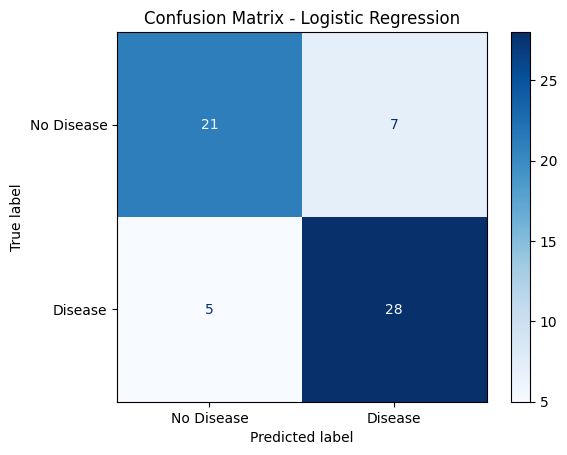

In [24]:
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease","Disease"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

* Logistic Regression correctly classifies the large majority of test patients, with only a small number of false positives and false negatives.

## 15. Feature Importance (Random Forest, for reference)

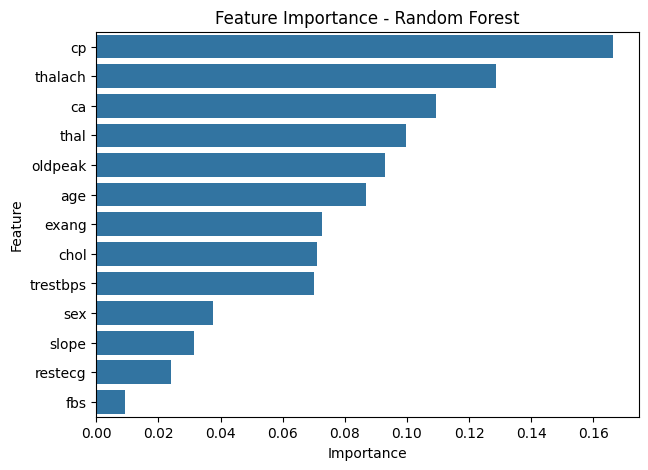

In [25]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(7,5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

* `cp` (chest pain type), `ca` (number of major vessels) and `thalach` (max heart rate) are the most influential features, which aligns with these same features driving Logistic Regression's strong performance.

## 16. Conclusion

* **Best model:** Logistic Regression is selected as the best-performing model. It achieves the highest Accuracy (0.803), F1-score (0.824) and ROC-AUC (0.871) among the four models tested, edging out Random Forest (AUC 0.870) and clearly ahead of the Decision Tree and KNN.
* **Why it wins:** The heart disease features here (e.g. `cp`, `thalach`, `oldpeak`) relate to the target in a largely linear, additive way after scaling, so a simple linear decision boundary generalizes better on this small dataset (241 training rows) than the more flexible but higher-variance Decision Tree, while matching the ensemble Random Forest's performance.
* **Practical note:** Logistic Regression is also the most interpretable of the four models, which is a meaningful bonus in a clinical context where understanding *why* a prediction was made matters as much as the prediction itself.